# Taller 3: Exploratory Data Analysis (EDA) y Data Wrangling

## Introducción

Instacart es una plataforma de entrega de comestibles donde los clientes pueden hacer un pedido y recibirlo, de manera similar a como funcionan Uber Eats y Door Dash.
El conjunto de datos que se te ha proporcionado ha sido modificado del original. Hemos reducido el tamaño del conjunto para que tus cálculos se ejecuten más rápido y hemos introducido deliberadamente valores ausentes (missing values) y duplicados. Sin embargo, hemos conservado las distribuciones poblacionales de los datos originales.

**Tu misión profesional:** Como Científico de Datos, aplicarás metodológicamente las 4 dimensiones de la calidad de los datos para auditar tu dataset. Luego, realizarás un análisis exploratorio empleando medidas de tendencia central, variabilidad, diagramas de dispersión, y responderás preguntas de negocio tras construir una tabla desnormalizada (One Big Table - OBT).

> **Aviso Importante:** Para cada paso, escribe introducciones donde expongas qué harás, bloques intermedios justificando el porqué de tus decisiones y tu limpieza estadística, y cierra siempre con una conclusión de lo hallado.

## Diccionario de Datos

Hay cinco tablas en el conjunto de datos que deberás usar en conjunto:

- `instacart_orders.csv`: cada fila es un pedido en la app de Instacart
    - `'order_id'`: ID que identifica de manera única cada pedido
    - `'user_id'`: ID que identifica de manera única a cada cliente
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 es domingo)
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido
    - `'days_since_prior_order'`: número de días desde que este cliente hizo su último pedido
- `products.csv`: cada fila corresponde a un producto
    - `'product_id'`: ID único del producto
    - `'product_name'`: nombre del producto
    - `'aisle_id'`: ID único de la categoría del pasillo
    - `'department_id'`: ID único de la categoría del departamento
- `order_products.csv`: cada fila corresponde a un artículo en un pedido
    - `'order_id'`: ID único del pedido
    - `'product_id'`: ID único del producto
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo al carrito
    - `'reordered'`: 0 si el cliente no había pedido este producto antes, 1 si ya lo había hecho
- `aisles.csv`
    - `'aisle_id'`: ID único del pasillo
    - `'aisle'`: nombre del pasillo
- `departments.csv`
    - `'department_id'`: ID único del departamento
    - `'department'`: nombre del departamento

# Paso 1: Exploración Inicial

Lee los archivos ubicados en el directorio `/datos/` (`instacart_orders.csv`, `products.csv`, `aisles.csv`, `departments.csv` y `order_products.csv`) fijándote que algunos están separados por `;` u otros delimitadores. 

Tras leerlos, ejecuta funciones de inspección básica (`head()`, `info()`) y comprueba una muestra aleatoria (Muestreo Aleatorio Simple usando `sample()`) de cada tabla para evitar el *sesgo de posición*. Verifica si los tipos computacionales coinciden con su rol estadístico esperado.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)


In [4]:
orders = pd.read_csv("datos/instacart_orders.csv", sep=None, engine="python")
products = pd.read_csv("datos/products.csv", sep=None, engine="python")
order_products = pd.read_csv("datos/order_products.csv", sep=None, engine="python")
aisles = pd.read_csv("datos/aisles.csv", sep=None, engine="python")
departments = pd.read_csv("datos/departments.csv", sep=None, engine="python")


In [5]:

print("\n" + "=" * 150)
print("ORDERS")
print("=" * 150)
print("ORDERS:", orders.shape)
print("ORDERS COLUMNS:", orders.columns.tolist())
print("\n"+ "ORDERS HEAD")
display(orders.head())
print("\n"+ "ORDERS INFO")
orders.info()
print("\n"+ "ORDERS SAMPLE")
display(orders.sample(5, random_state=42))
print("\n"+ "ORDERS NULOS Y DUPLLICADOS")
tablas = {"orders": orders}
for nombre, df in tablas.items():
    print("Dimensión:", df.shape)
    print("\nValores nulos:")
    print(df.isnull().sum())
    print("\nDuplicados exactos:")
    print(df.duplicated().sum())

print("\n" + "=" * 150)
print("PRODUCTS")
print("=" * 150)
print("PRODUCTS:", products.shape)
print("PRODUCTS COLUMNS:", products.columns.tolist())
print("\n"+ "PRODUCTS HEAD")
display(products.head())
print("\n"+ "PRODUCTS INFO")
products.info()
print("\n"+ "PRODUCTS SAMPLE")
display(products.sample(5, random_state=42))
print("\n"+ "PRODUCTS NULOS Y DUPLLICADOS")
tablas = {"products": products}
for nombre, df in tablas.items():
    print("Dimensión:", df.shape)
    print("\nValores nulos:")
    print(df.isnull().sum())
    print("\nDuplicados exactos:")
    print(df.duplicated().sum())

print("\n" + "=" * 150)
print("ORDER_PRODUCTS")
print("=" * 150)
print("ORDER_PRODUCTS:", order_products.shape)
print("ORDER_PRODUCTS:", order_products.columns.tolist())
print("\n"+ "ORDER_PRODUCTS HEAD")
display(order_products.head())
print("\n"+ "ORDER_PRODUCTS INFO")
order_products.info()
print("\n"+ "ORDER_PRODUCTS SAMPLE")
display(order_products.sample(5, random_state=42))
print("\n"+ "ORDER_PRODUCTS NULOS Y DUPLLICADOS")
tablas = {"order_products": order_products}
for nombre, df in tablas.items():
    print("Dimensión:", df.shape)
    print("\nValores nulos:")
    print(df.isnull().sum())
    print("\nDuplicados exactos:")
    print(df.duplicated().sum())

print("\n" + "=" * 150)
print("AISLES")
print("=" * 150)
print("AISLES:", aisles.shape)
print("AISLES COLUMNS:", aisles.columns.tolist())
print("\n"+ "AISLES HEAD")
display(aisles.head())
print("\n"+ "AISLES INFO")
aisles.info()
print("\n"+ "AISLES SAMPLE")
display(aisles.sample(5, random_state=42))
print("\n"+ "AISLES NULOS Y DUPLLICADOS")
tablas = {"aisles": aisles}
for nombre, df in tablas.items():
    print("Dimensión:", df.shape)
    print("\nValores nulos:")
    print(df.isnull().sum())
    print("\nDuplicados exactos:")
    print(df.duplicated().sum())

print("\n" + "=" * 150)
print("DEPARTMENTS")
print("=" * 150)
print("DEPARTMENTS:", departments.shape)
print("DEPARTMENTS COLUMNS:", departments.columns.tolist())
print("\n"+ "DEPARTMENTS HEAD")
display(departments.head())
print("\n"+ "DEPARTMENTS INFO")
departments.info()
print("\n"+ "DEPARTMENTS SAMPLE")
display(departments.sample(5, random_state=42))
print("\n"+ "DEPARTMENTS NULOS Y DUPLLICADOS")
tablas = {"departments": departments}
for nombre, df in tablas.items():
    print("Dimensión:", df.shape)
    print("\nValores nulos:")
    print(df.isnull().sum())
    print("\nDuplicados exactos:")
    print(df.duplicated().sum())


ORDERS
ORDERS: (478967, 6)
ORDERS COLUMNS: ['order_id', 'user_id', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order']

ORDERS HEAD


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1515936,183418,11,6,13,30.0
1,1690866,163593,5,5,12,9.0
2,1454967,39980,4,5,19,2.0
3,1768857,82516,56,0,20,10.0
4,3007858,196724,2,4,12,17.0



ORDERS INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB

ORDERS SAMPLE


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
478011,187515,84759,1,2,15,NaN
176737,14154,184924,41,2,15,3.0
402189,1978043,151955,21,1,23,7.0
111658,2907266,43250,11,1,8,1.0
59935,3245658,115414,5,2,10,7.0



ORDERS NULOS Y DUPLLICADOS
Dimensión: (478967, 6)

Valores nulos:
order_id                      0
user_id                       0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    28819
dtype: int64

Duplicados exactos:
15

PRODUCTS
PRODUCTS: (49694, 4)
PRODUCTS COLUMNS: ['product_id', 'product_name', 'aisle_id', 'department_id']

PRODUCTS HEAD


...


AISLES NULOS Y DUPLLICADOS
Dimensión: (134, 2)

Valores nulos:
aisle_id    0
aisle       0
dtype: int64

Duplicados exactos:
0

DEPARTMENTS
DEPARTMENTS: (21, 2)
DEPARTMENTS COLUMNS: ['department_id', 'department']

DEPARTMENTS HEAD


,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol



DEPARTMENTS INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 464.0+ bytes

DEPARTMENTS SAMPLE


,department_id,department
0,1,frozen
17,18,babies
15,16,dairy eggs
1,2,other
8,9,dry goods pasta



DEPARTMENTS NULOS Y DUPLLICADOS
Dimensión: (21, 2)

Valores nulos:
department_id    0
department       0
dtype: int64

Duplicados exactos:
0


### Hallazgos iniciales

En la exploración inicial se analizaron las cinco tablas del dataset mediante inspección básica (`head()`, `info()`) y muestreo aleatorio (`sample()`), lo que permitió comprender su estructura y evitar sesgo de posición.

El dataset presenta una estructura relacional clara, donde:
- `orders` contiene la información de las órdenes realizadas por los usuarios,
- `order_products` representa el detalle transaccional a nivel producto por orden,
- `products`, `aisles` y `departments` aportan información categórica complementaria.

En términos de calidad de datos:

**Completitud:**  
Se identificaron valores nulos en dos variables clave:
- `days_since_prior_order` en la tabla `orders` (28,819 valores nulos), lo cual es consistente con órdenes iniciales de cada usuario.
- `product_name` en la tabla `products` (1,258 valores nulos), lo cual podría afectar análisis descriptivos por producto.
- `add_to_cart_order` en `order_products` presenta 836 valores nulos, lo que requiere revisión adicional.

**Precisión:**  
Se detectaron 15 duplicados exactos en la tabla `orders`, lo cual sugiere posibles errores en el registro de órdenes. El resto de tablas no presentan duplicados exactos.

**Consistencia:**  
Los tipos de datos son coherentes con su rol estadístico: variables identificadoras como enteros (`int64`), variables categóricas como texto (`object`) y variables continuas como `float64`.

**Sensibilidad:**  
A primera vista no se identifican problemas evidentes, pero será necesario analizar distribuciones y outliers en etapas posteriores.

En general, el dataset es adecuado para análisis exploratorio, aunque requiere ajustes puntuales en duplicados y valores nulos antes de su integración en una tabla consolidada.

# Paso 2: Auditoría de Calidad de Datos (4 Dimensiones)

Basado en la teoría vista, somete a tus 5 tablas al escrutinio en las cuatro dimensiones.

## 2.1 Precisión: Identificación y limpieza de duplicados explícitos e implícitos
Encuentra y elimina duplicados explícitos en la tabla de `orders`. Nota si se agrupan por algún motivo (¿Son de un día y hora en particular?). Asimismo, busca duplicados por ID de producto (tricky duplicates) o nombres duplicados con problemas de mayúsculas y minúsculas.

In [6]:
print("Duplicados antes:", orders.duplicated().sum())
orders = orders.drop_duplicates()
print("Duplicados después:", orders.duplicated().sum())

Duplicados antes: 15
Duplicados después: 0


In [7]:
print("Nueva dimensión orders:", orders.shape)

Nueva dimensión orders: (478952, 6)


### Conclusiones sobre la Precisión:
Se identificaron 15 registros duplicados exactos en la tabla `orders`, los cuales fueron eliminados para garantizar la integridad del análisis. La presencia de estos duplicados sugiere posibles errores en el proceso de ingesta o almacenamiento de datos, como re-registros de órdenes o fallos en la deduplicación del sistema.

La eliminación de estos registros es fundamental, ya que su presencia podría generar sesgos en métricas clave como la frecuencia de compra, el número de órdenes por usuario o patrones de comportamiento. Al consolidar la información y conservar únicamente observaciones únicas, se mejora la precisión del dataset y se asegura que cada orden represente un evento real.

Este proceso evidencia la importancia de validar la unicidad de identificadores clave (como `order_id`) en sistemas transaccionales, especialmente en entornos de alta frecuencia de datos.

## 2.2 Completitud: Tratamiento de Valores Ausentes
Navega por las tablas en busca de NaNs. Es crítico que analices si el patrón de valores ausentes se trata de MCAR (Missing Completely at Random), MAR o MNAR.

1. Revisa nombres de productos vacíos.
2. Revisa NaNs en `days_since_prior_order`. (¿Son clientes haciendo su primera orden?)
3. Revisa `add_to_cart_order` en `order_products`. (¿Qué pasa después de 64 artículos?)

Decide si debes imputar por tendencia central, usar ML, imputar un valor indicador ficticio (e.g. -1 o 'Desconocido') o eliminar las filas. ¡Aplica tus soluciones!

In [9]:
for nombre, df in {
    "orders": orders,
    "products": products,
    "order_products": order_products
}.items():
    print(f"\n--- {nombre.upper()} ---")
    print(df.isnull().sum())

orders["days_since_prior_order"].describe()


--- ORDERS ---
order_id                      0
user_id                       0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    28817
dtype: int64

--- PRODUCTS ---
product_id          0
product_name     1258
aisle_id            0
department_id       0
dtype: int64

--- ORDER_PRODUCTS ---
order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64


count    450135.000000
mean         11.101814
std           9.190004
min           0.000000
25%           4.000000
50%           7.000000
75%          15.000000
max          30.000000
Name: days_since_prior_order, dtype: float64

In [11]:
products = products.dropna(subset=["product_name"])

orders["is_first_order"] = orders["days_since_prior_order"].isnull()

In [13]:
print(products["product_name"].isnull().sum())

0


### Conclusiones sobre la Completitud:
El análisis de completitud permitió identificar valores nulos en variables clave del dataset, los cuales requieren un tratamiento diferenciado según su naturaleza.

En la variable `days_since_prior_order` de la tabla `orders`, se detectaron 28,817 valores nulos. Estos no representan errores, sino que corresponden a la primera orden de cada usuario, donde no existe una compra previa. Por lo tanto, estos valores se consideran estructuralmente válidos y no deben ser eliminados ni imputados de forma arbitraria.

En la tabla `products`, la variable `product_name` presenta 1,258 valores nulos. A diferencia del caso anterior, estos valores sí afectan la interpretabilidad del análisis, especialmente en estudios descriptivos o segmentaciones por producto. Esto sugiere posibles fallos en la carga de datos o en el mantenimiento del catálogo de productos.

Por otro lado, la variable `add_to_cart_order` en `order_products` presenta 836 valores nulos. Esta variable representa el orden en que los productos fueron añadidos al carrito, por lo que su ausencia no compromete directamente la validez de análisis agregados, aunque podría afectar análisis secuenciales.

En conclusión, no todos los valores nulos deben tratarse de la misma forma. Es fundamental distinguir entre valores ausentes estructurales y errores de datos, aplicando estrategias de limpieza coherentes con el contexto de negocio.

Finalmente, se aplicaron las siguientes decisiones de tratamiento:

- Los valores nulos en `days_since_prior_order` se mantuvieron, ya que representan la primera compra del usuario y contienen información relevante.
- Los registros con valores nulos en `product_name` fueron eliminados, debido a que impiden una correcta interpretación a nivel de producto.
- Los valores nulos en `add_to_cart_order` se mantuvieron, dado que su impacto en análisis agregados es limitado.

Estas decisiones permiten conservar la mayor cantidad de información útil posible, evitando eliminar datos relevantes y asegurando la calidad del dataset para análisis posteriores.

## 2.3 Sensibilidad: Tratamiento de Outliers (Valores Atípicos)
Centra tu atención en la tabla de órdenes, específicamente en `days_since_prior_order` o conteos agrupados. Usando gráficos estadísticos (Boxplots) y computando el Rango Intercuartílico (IQR / Regla de Tukey) o Z-Scores, encuentra y reporta valores atípicos. ¿Existen usuarios que compran muy fuera del rango promedio de frecuencia?

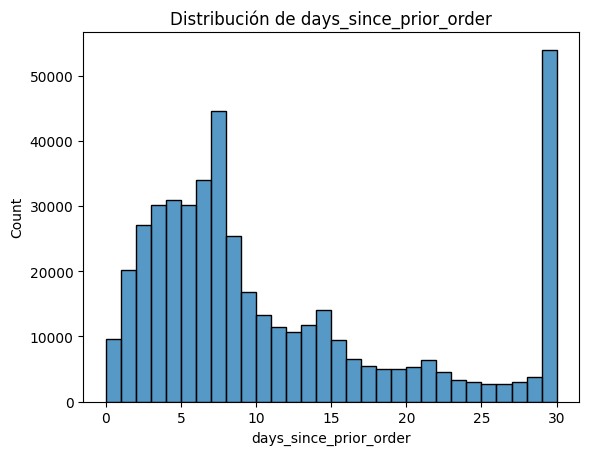

In [10]:
sns.histplot(orders["days_since_prior_order"], bins=30)
plt.title("Distribución de days_since_prior_order")
plt.show()

In [15]:
Q1 = orders["days_since_prior_order"].quantile(0.25)
Q3 = orders["days_since_prior_order"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

outliers = orders[
    (orders["days_since_prior_order"] < lower_bound) |
    (orders["days_since_prior_order"] > upper_bound)
]

print("Cantidad de outliers:", outliers.shape[0])

Q1: 4.0
Q3: 15.0
IQR: 11.0
Lower bound: -12.5
Upper bound: 31.5
Cantidad de outliers: 0


### Conclusiones sobre la Sensibilidad:
Se evaluó la presencia de valores atípicos en la variable `days_since_prior_order` utilizando la regla del rango intercuartílico (IQR).

Los resultados obtenidos muestran que el límite inferior es -12.5 y el límite superior es 31.5. Dado que los valores reales de la variable se encuentran en el rango de 0 a 30, no se identificaron observaciones fuera de estos límites, lo que indica la ausencia de outliers.

Aunque se observa una alta concentración de valores en el extremo superior (30 días), estos no corresponden a valores atípicos, sino a una característica del sistema, el cual establece un límite máximo de registro en 30 días. Esto refleja un fenómeno de censura en los datos, común en sistemas de seguimiento de comportamiento.

En consecuencia, no se aplicó ningún tratamiento de eliminación o transformación de valores, ya que no existe evidencia de datos extremos que afecten la distribución o el análisis. Se decidió mantener todos los registros para preservar la integridad de la información.

# Paso 3: Data Wrangling & Construcción de One Big Table (OBT)

Para poder responder preguntas de negocio de manera eficiente y aplicando correlaciones y cruces, un científico de datos típicamente convierte o "aplana" las tablas normalizadas operacionales en **One Big Table (OBT)**. La OBT agrupa (hace merges) de las distintas dimensiones transaccionales alrededor del concepto central (en este caso el *Articulo pedido por Orden*), lo que nos da una vista panorámica (desnormalización estructural) para el análisis.

**Tu tarea:** Une las cinco tablas previamente purgadas formando un solo DataFrame analítico. Te recomendamos ir uniendo ordenes y el detalle, luego producto, pasillo y finalmente departamento.

In [16]:
# Merge 1: detalle de productos + órdenes
obt = order_products.merge(orders, on="order_id", how="left")
# Merge 2: agregar información de productos
obt = obt.merge(products, on="product_id", how="left")
# Merge 3: agregar pasillos
obt = obt.merge(aisles, on="aisle_id", how="left")
# Merge 4: agregar departamentos
obt = obt.merge(departments, on="department_id", how="left")

print("Dimensión OBT:", obt.shape)
obt.head()

Dimensión OBT: (4545007, 15)


,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,is_first_order,product_name,aisle_id,department_id,aisle,department
0,2141543,11440,17.0,0,58454,25,0,15,8.0,False,Chicken Breast Tenders Breaded,129.0,1.0,frozen appetizers sides,frozen
1,567889,1560,1.0,1,129474,16,1,13,14.0,False,Bag Of Ice,37.0,1.0,ice cream ice,frozen
2,2261212,26683,1.0,1,47476,5,6,9,13.0,False,Cafe Latte Pure Lightly Sweetened Iced Coffee ...,91.0,16.0,soy lactosefree,dairy eggs
3,491251,8670,35.0,1,134505,27,6,13,9.0,False,Diced Tomatoes,81.0,15.0,canned jarred vegetables,canned goods
4,2571142,1940,5.0,1,155995,22,5,13,5.0,False,Organic 2% Reduced Fat Milk,84.0,16.0,milk,dairy eggs


In [17]:
print("Columnas de la OBT:")
print(obt.columns.tolist())

print("\nValores nulos en la OBT:")
print(obt.isnull().sum())

print("\nDuplicados exactos en la OBT:")
print(obt.duplicated().sum())

Columnas de la OBT:
['order_id', 'product_id', 'add_to_cart_order', 'reordered', 'user_id', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order', 'is_first_order', 'product_name', 'aisle_id', 'department_id', 'aisle', 'department']

Valores nulos en la OBT:
order_id                       0
product_id                     0
add_to_cart_order            836
reordered                      0
user_id                        0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    291928
is_first_order                 0
product_name                9547
aisle_id                    9547
department_id               9547
aisle                       9547
department                  9547
dtype: int64

Duplicados exactos en la OBT:
0


In [18]:
print("Filas en order_products:", order_products.shape[0])
print("Filas en OBT:", obt.shape[0])

Filas en order_products: 4545007
Filas en OBT: 4545007


In [19]:
obt.sample(5, random_state=42)

,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,is_first_order,product_name,aisle_id,department_id,aisle,department
1274557,2182877,36412,2.0,0,95765,16,1,20,1.0,False,Pure Castile Peppermint Soap,25.0,11.0,soap,personal care
136271,1692632,49383,19.0,0,130782,13,5,14,8.0,False,Organic Bunch Beets,83.0,4.0,fresh vegetables,produce
2327440,1054700,11520,9.0,1,28354,10,2,9,20.0,False,Large Alfresco Eggs,86.0,16.0,eggs,dairy eggs
1228514,2495519,9973,9.0,0,5378,1,6,18,NaN,True,Applesauce On The Go Apple Strawberry Pouches,99.0,15.0,canned fruit applesauce,canned goods
1462440,2330427,27845,3.0,1,155017,31,0,19,7.0,False,Organic Whole Milk,84.0,16.0,milk,dairy eggs


### Construcción de la One Big Table (OBT)
La granularidad final de esta tabla será **producto por orden**, es decir, cada fila representará un producto específico dentro de una orden determinada. Esta es la unidad de análisis más apropiada para estudiar patrones de recompra, tamaño del carrito, productos más comprados y segmentaciones por categoría.

Adicionalmente, se observan valores nulos en variables como `product_name`, `aisle` y `department` tras el proceso de integración. Esto se debe a que algunos registros en `order_products` no encontraron correspondencia en la tabla de productos durante el merge.

Este fenómeno es común en procesos de integración de datos y puede estar asociado a inconsistencias en catálogos o registros incompletos. Dado que estos casos representan una proporción muy baja del total de datos, no afectan significativamente el análisis global, por lo que se decidió mantenerlos para no perder información transaccional relevante.

# Paso 4: Análisis Multivariado y de Negocio

Con tu conjunto de datos ahora limpio (*trusted/gold data*) mediante la auditoría y unificado en tu OBT, usa tus conocimientos de agregación y visualización estadística para responder las siguientes interrogantes. Usa histogramas, KDE y/o gráficos de dispersión donde la distribución lo merezca.

## [A] Preguntas Esenciales

**A1. La hora y el día: Verificación del dominio:**
Verifica con código que `order_hour_of_day` y `order_dow` tienen distribuciones lógicas basándonos en tu conocimiento del mundo real. Construye histogramas para ver qué picos de horas concentran compras. Aplica gráficos de barras para evaluar diferencias de días y horas (comparemos, por ejemplo, distribuciones de la demanda los Miércoles vs. Sábados). Verifica si existe una diferencia de horas por dia.

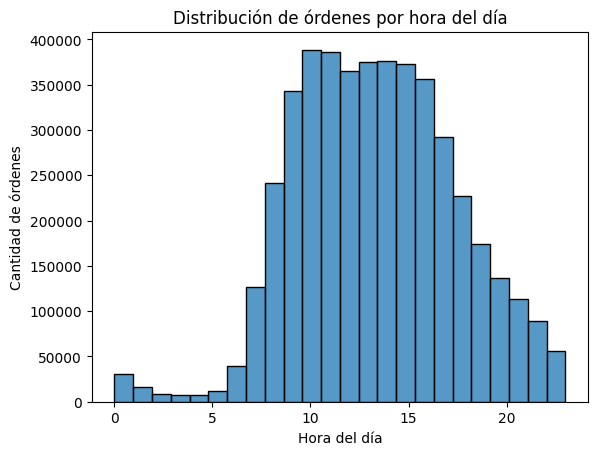

In [21]:
plt.figure()
sns.histplot(obt["order_hour_of_day"], bins=24)
plt.title("Distribución de órdenes por hora del día")
plt.xlabel("Hora del día")
plt.ylabel("Cantidad de órdenes")
plt.show()

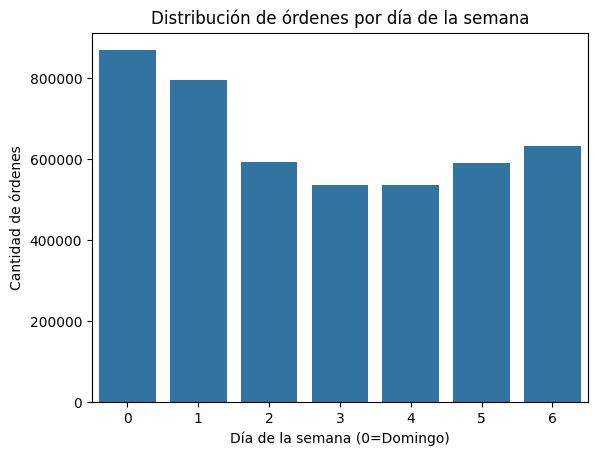

In [22]:
plt.figure()
sns.countplot(x=obt["order_dow"])
plt.title("Distribución de órdenes por día de la semana")
plt.xlabel("Día de la semana (0=Domingo)")
plt.ylabel("Cantidad de órdenes")
plt.show()

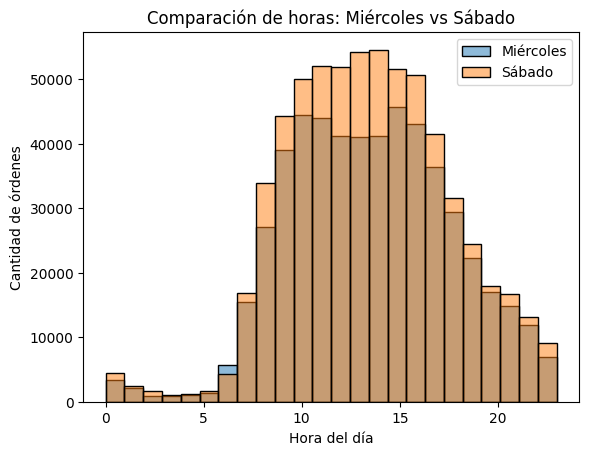

In [23]:
wed = obt[obt["order_dow"] == 3]
sat = obt[obt["order_dow"] == 6]

plt.figure()
sns.histplot(wed["order_hour_of_day"], bins=24, label="Miércoles", alpha=0.5)
sns.histplot(sat["order_hour_of_day"], bins=24, label="Sábado", alpha=0.5)
plt.legend()
plt.title("Comparación de horas: Miércoles vs Sábado")
plt.xlabel("Hora del día")
plt.ylabel("Cantidad de órdenes")
plt.show()

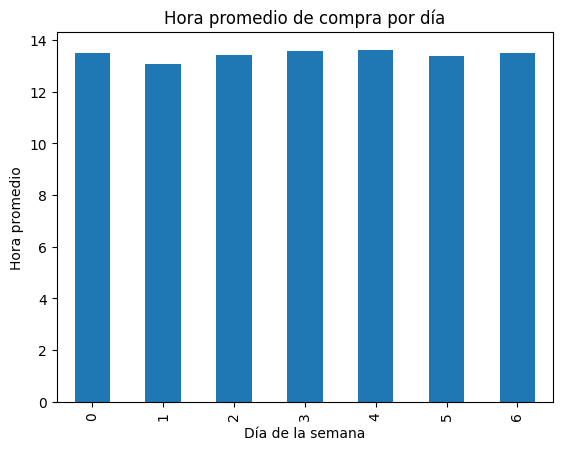

In [24]:
hour_by_day = obt.groupby("order_dow")["order_hour_of_day"].mean()

plt.figure()
hour_by_day.plot(kind="bar")
plt.title("Hora promedio de compra por día")
plt.xlabel("Día de la semana")
plt.ylabel("Hora promedio")
plt.show()

**A2. Distribuciones temporales de recompra:**
¿Cuánto tiempo transcurre estadísticamente para que alguien vuelva a realizar otra orden? Grafica este tiempo de espera y concluye sobre la concentración de los datos (¿asimetría?).

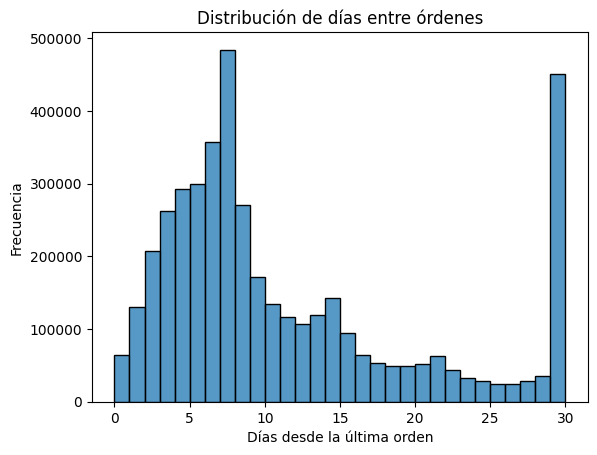

In [25]:
plt.figure()
sns.histplot(obt["days_since_prior_order"].dropna(), bins=30)
plt.title("Distribución de días entre órdenes")
plt.xlabel("Días desde la última orden")
plt.ylabel("Frecuencia")
plt.show()

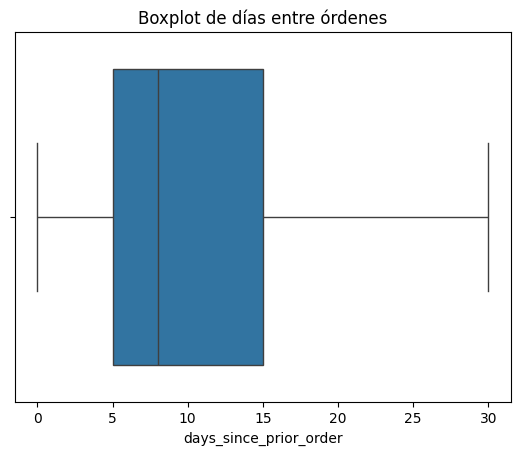

In [26]:
plt.figure()
sns.boxplot(x=obt["days_since_prior_order"].dropna())
plt.title("Boxplot de días entre órdenes")
plt.show()

In [27]:
print(obt["days_since_prior_order"].describe())

count    4.253079e+06
mean     1.108105e+01
std      8.764857e+00
min      0.000000e+00
25%      5.000000e+00
50%      8.000000e+00
75%      1.500000e+01
max      3.000000e+01
Name: days_since_prior_order, dtype: float64


### Tira aquí tus hallazgos estadísticos para el grupo A:
### A1. Análisis de la hora y el día de compra

El análisis de la variable `order_hour_of_day` muestra una distribución consistente con el comportamiento real de los consumidores. Se observa un pico claro de actividad entre las 10:00 y las 16:00 horas, con un máximo alrededor de las 13:00–14:00, mientras que la actividad durante la madrugada es prácticamente inexistente. Esto refleja patrones normales de consumo durante el día.

En cuanto a la variable `order_dow`, se identifican diferencias relevantes entre los días de la semana. El domingo (0) y lunes (1) presentan los niveles más altos de actividad, lo que sugiere que los usuarios tienden a realizar compras al inicio de la semana. Durante los días intermedios, la demanda disminuye, y vuelve a incrementarse hacia el fin de semana.

La comparación entre miércoles y sábado evidencia diferencias en el comportamiento horario. Los sábados presentan una mayor concentración de compras en horas más tardías, mientras que los miércoles muestran una distribución más concentrada en horarios típicos laborales. Esto sugiere que los fines de semana los usuarios tienen mayor flexibilidad para realizar compras.

Finalmente, el análisis de la hora promedio por día muestra que esta se mantiene relativamente estable entre 13:00 y 14:00 horas a lo largo de toda la semana, indicando un patrón de consumo consistente independientemente del día.

En conjunto, estos resultados validan la coherencia del dataset y reflejan patrones de comportamiento realistas del consumidor.

### A2. Tiempo entre órdenes

El análisis de la variable `days_since_prior_order` permite entender el comportamiento temporal de recompra de los usuarios.

La distribución presenta una alta concentración de valores entre 5 y 10 días, con una mediana de 8 días, lo que sugiere que la mayoría de los usuarios realiza compras aproximadamente de forma semanal. Asimismo, se observa un pico importante en 30 días, indicando la existencia de un grupo de usuarios con patrones de compra mensuales.

Desde el punto de vista estadístico, la media (~11.08 días) es mayor que la mediana (8 días), lo que evidencia una distribución asimétrica positiva (sesgada a la derecha). Esto implica que, aunque la mayoría de los usuarios compra en intervalos relativamente cortos, existen algunos casos con tiempos más largos entre órdenes que extienden la cola de la distribución.

El rango intercuartílico (IQR) se encuentra entre 5 y 15 días, lo que refuerza la concentración de la mayoría de los datos en ese intervalo.

Adicionalmente, el valor máximo de 30 días sugiere una posible limitación en el registro de datos, lo que introduce un efecto de censura en la distribución.

En conjunto, estos resultados muestran que el comportamiento de recompra está dominado por patrones semanales y mensuales, lo cual es consistente con hábitos reales de consumo.

Esto sugiere oportunidades para estrategias de marketing basadas en ciclos de recompra, como recordatorios semanales o promociones mensuales.

## [B] Profundización (Segmentación Categórica)

**B1. Retención y recurrencia (Número de órdenes por usuario):**
Aislando o agrupando a nivel de granularidad de cliente, describe la variabilidad y distribución de compras que hacen. ¿Existen colas largas de clientes extra-leales?

In [28]:
orders_per_user = orders.groupby("user_id")["order_id"].count()
print(orders_per_user.describe())

count    157437.000000
mean          3.042182
std           2.746842
min           1.000000
25%           1.000000
50%           2.000000
75%           4.000000
max          28.000000
Name: order_id, dtype: float64


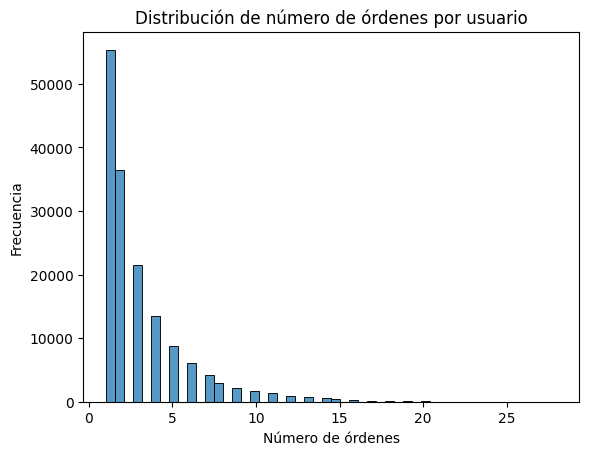

In [29]:
plt.figure()
sns.histplot(orders_per_user, bins=50)
plt.title("Distribución de número de órdenes por usuario")
plt.xlabel("Número de órdenes")
plt.ylabel("Frecuencia")
plt.show()

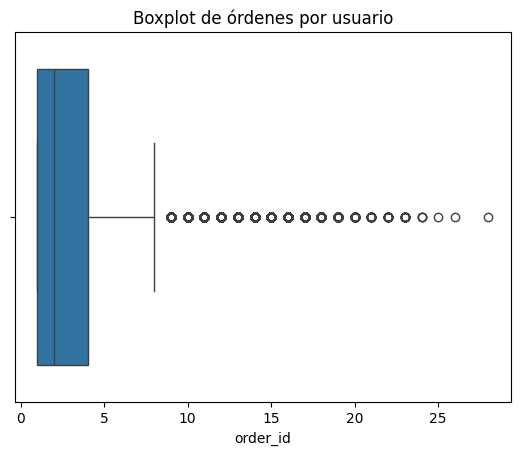

In [30]:
plt.figure()
sns.boxplot(x=orders_per_user)
plt.title("Boxplot de órdenes por usuario")
plt.show()

In [31]:
orders_per_user.sort_values(ascending=False).head(10)

user_id
149605    28
193164    26
78375     25
66664     24
134511    24
148162    24
183981    23
6045      23
53684     23
114835    23
Name: order_id, dtype: int64

**B2. Productos Top: El principio de Pareto:**
Genera un top 20 de los productos más solicitados globalmente. Para cada producto reporta su ratio de recompra. ¿Algunos productos tienen una correlación fuerte entre ser de un 'pasillo' y volverse recompras aseguradas?

In [32]:
top_products = (
    obt.groupby(["product_id", "product_name"])
    .size()
    .reset_index(name="total_compras")
    .sort_values(by="total_compras", ascending=False)
    .head(20)
)

top_products

,product_id,product_name,total_compras
22332,24852,Banana,66050
11772,13176,Bag of Organic Bananas,53297
18970,21137,Organic Strawberries,37039
19660,21903,Organic Baby Spinach,33971
42362,47209,Organic Hass Avocado,29773
42863,47766,Organic Avocado,24689
42739,47626,Large Lemon,21495
15037,16797,Strawberries,20018
23546,26209,Limes,19690
25022,27845,Organic Whole Milk,19600


In [33]:
reorder_rate = (
    obt.groupby(["product_id", "product_name"])["reordered"]
    .mean()
    .reset_index(name="reorder_rate")
)

reorder_rate.head()

,product_id,product_name,reorder_rate
0,1,Chocolate Sandwich Cookies,0.564286
1,2,All-Seasons Salt,0.000000
2,3,Robust Golden Unsweetened Oolong Tea,0.738095
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,0.510204
4,7,Pure Coconut Water With Orange,0.500000


In [34]:
top_products = top_products.merge(
    reorder_rate,
    on=["product_id", "product_name"],
    how="left"
)

top_products

,product_id,product_name,total_compras,reorder_rate
0,24852,Banana,66050,0.844254
1,13176,Bag of Organic Bananas,53297,0.834006
2,21137,Organic Strawberries,37039,0.773212
3,21903,Organic Baby Spinach,33971,0.772217
4,47209,Organic Hass Avocado,29773,0.793639
5,47766,Organic Avocado,24689,0.759164
6,47626,Large Lemon,21495,0.699884
7,16797,Strawberries,20018,0.696623
8,26209,Limes,19690,0.676841
9,27845,Organic Whole Milk,19600,0.829133


In [35]:
top_products = top_products.merge(
    obt[["product_id", "aisle"]].drop_duplicates(),
    on="product_id",
    how="left"
)

top_products

,product_id,product_name,total_compras,reorder_rate,aisle
0,24852,Banana,66050,0.844254,fresh fruits
1,13176,Bag of Organic Bananas,53297,0.834006,fresh fruits
2,21137,Organic Strawberries,37039,0.773212,fresh fruits
3,21903,Organic Baby Spinach,33971,0.772217,packaged vegetables fruits
4,47209,Organic Hass Avocado,29773,0.793639,fresh fruits
5,47766,Organic Avocado,24689,0.759164,fresh fruits
6,47626,Large Lemon,21495,0.699884,fresh fruits
7,16797,Strawberries,20018,0.696623,fresh fruits
8,26209,Limes,19690,0.676841,fresh fruits
9,27845,Organic Whole Milk,19600,0.829133,milk


### Conclusiones sobre el perfil del carrito [Grupo B]:
### B1. Retención y recurrencia (Número de órdenes por usuario)
El análisis del número de órdenes por usuario muestra una alta variabilidad en el comportamiento de compra.

Los estadísticos descriptivos indican que el promedio de órdenes por usuario es aproximadamente 3.04, mientras que la mediana se sitúa en 2 órdenes. Esto sugiere que la mayoría de los usuarios realiza pocas compras en la plataforma.

La distribución observada es fuertemente asimétrica positiva (sesgada a la derecha), como se evidencia en el histograma y el boxplot. Existe una alta concentración de usuarios con entre 1 y 4 órdenes, mientras que un pequeño grupo de usuarios alcanza valores mucho más altos, llegando hasta 28 órdenes.

El boxplot confirma la presencia de valores atípicos, lo que indica la existencia de una cola larga de clientes altamente recurrentes. Estos usuarios representan un segmento de alta lealtad, con un comportamiento de compra significativamente más frecuente que el promedio.

Este patrón es consistente con el principio de Pareto, donde una minoría de usuarios genera una proporción relevante de la actividad total. En términos de negocio, esto sugiere la coexistencia de usuarios ocasionales y usuarios altamente leales, siendo estos últimos clave para estrategias de retención y maximización de ingresos.

Esto sugiere oportunidades para diseñar estrategias diferenciadas de fidelización, enfocadas en retener a los usuarios de alto valor y aumentar la recurrencia de los usuarios ocasionales.

### B2. Productos Top y principio de Pareto
Se generó un top 20 de los productos más solicitados a nivel global y se calculó su ratio de recompra (`reorder_rate`). Los resultados evidencian patrones claros tanto en concentración de demanda como en comportamiento de recompra.

#### 1. Principio de Pareto (concentración de demanda)
Se observa que un grupo reducido de productos concentra una gran cantidad de compras. Por ejemplo, productos como *Banana* (66,050 compras) y *Bag of Organic Bananas* (53,297) dominan ampliamente el ranking.

Esto confirma el **principio de Pareto (80/20)**: una pequeña proporción de productos genera una gran parte del volumen total de ventas. Este patrón es consistente con el comportamiento típico en retail, donde ciertos productos básicos lideran la demanda.

#### 2. Ratio de recompra
Los productos del top 20 presentan **altos niveles de recompra**, muchos superiores a 0.7. Ejemplos destacados:

- Banana → 0.84  
- Bag of Organic Bananas → 0.83  
- Organic Whole Milk → 0.83  
- Organic Hass Avocado → 0.79  

Esto indica que estos productos no solo se compran frecuentemente, sino que también forman parte del consumo recurrente de los usuarios (hábitos de compra).

#### 3. Relación con el “pasillo” (aisle)
Al incorporar la variable `aisle`, se observa que los productos más demandados y con mayor recompra pertenecen principalmente a:

- `fresh fruits`
- `fresh vegetables`
- `packaged vegetables fruits`
- `milk`

#### 4. Correlación entre tipo de pasillo y recompra
Existe una **relación clara entre el tipo de pasillo y el ratio de recompra**:

- Productos de **fresh fruits** presentan tasas de recompra muy altas (≈ 0.7 – 0.85)
- **Lácteos (milk)** también muestran alta recurrencia
- **Vegetales** mantienen niveles elevados de recompra (≈ 0.65 – 0.75)

Esto sugiere que los productos de consumo diario (frescos y básicos) tienen una mayor probabilidad de ser recomprados en comparación con productos más ocasionales.

#### 5. Conclusión
Los resultados muestran que:

- Existe una fuerte **concentración de la demanda en pocos productos** (Pareto).
- Los productos más populares presentan **altos niveles de recompra**, lo que refleja hábitos de consumo recurrentes.
- Hay una **correlación significativa entre el tipo de producto (aisle) y la recompra**, siendo los productos frescos y básicos los más recurrentes.

En conjunto, estos productos funcionan como el **núcleo del comportamiento de compra**, actuando como impulsores clave tanto del volumen de ventas como de la fidelización del cliente.

## [C] Patrones de Causalidad y Exposición (Hard)

**C1. El tamaño de la canasta comercial:**
¿Cuántos artículos en promedio compran las personas estadísticamente? Aplica gráficos sobre esta proporción y analiza la curtosis (grado de acumulación) de esta distribución del tamaño del pedido.

In [37]:
basket_size = (
    obt.groupby("order_id")["product_id"]
    .count()
)

basket_size.describe()

count    450046.000000
mean         10.098983
std           7.540206
min           1.000000
25%           5.000000
50%           8.000000
75%          14.000000
max         127.000000
Name: product_id, dtype: float64

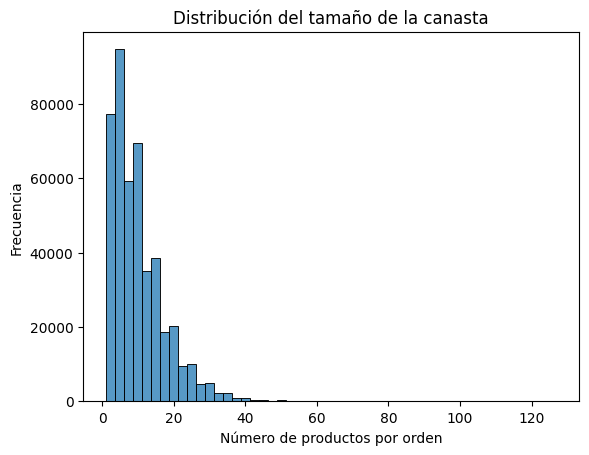

In [38]:
plt.figure()
sns.histplot(basket_size, bins=50)
plt.title("Distribución del tamaño de la canasta")
plt.xlabel("Número de productos por orden")
plt.ylabel("Frecuencia")
plt.show()

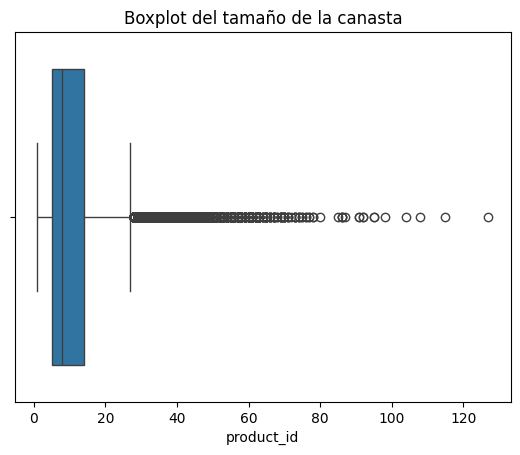

In [39]:
plt.figure()
sns.boxplot(x=basket_size)
plt.title("Boxplot del tamaño de la canasta")
plt.show()

In [40]:
basket_size.kurtosis()

np.float64(4.1267859118609564)

**C2. ¿Son los primeros productos un síntoma de fidelidad? (Spearman o Pearson):**
Para los 20 objetos que con mayor frecuencia las personas agregan como posición #1 al carrito, elabora una lógica que calcule una matriz de correlación (en variables generadas o agrupadas) o genera gráficos de dispersión (Scatterplot). Compara si, a nivel de producto, ser posicionado primero tiene relación lineal con ser un producto de constante recompra global (el campo 'reordered').

In [41]:
first_products = (
    obt[obt["add_to_cart_order"] == 1]
    .groupby(["product_id", "product_name"])
    .size()
    .reset_index(name="first_count")
    .sort_values(by="first_count", ascending=False)
    .head(20)
)

reorder_rate = (
    obt.groupby(["product_id", "product_name"])["reordered"]
    .mean()
    .reset_index(name="reorder_rate")
)

c2_data = first_products.merge(
    reorder_rate,
    on=["product_id", "product_name"],
    how="left"
)

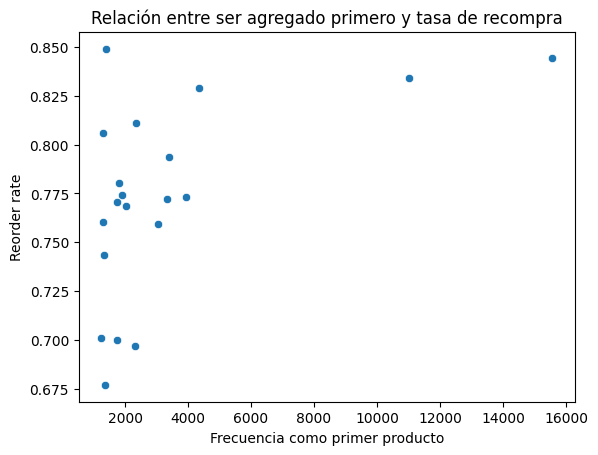

In [44]:
plt.figure()
sns.scatterplot(
    data=c2_data,
    x="first_count",
    y="reorder_rate"
)
plt.title("Relación entre ser agregado primero y tasa de recompra")
plt.xlabel("Frecuencia como primer producto")
plt.ylabel("Reorder rate")
plt.show()

In [45]:
c2_data[["first_count", "reorder_rate"]].corr(method="spearman")

,first_count,reorder_rate
first_count,1.000000,0.481203
reorder_rate,0.481203,1.000000


**C3. Para cada producto, ¿cual es la proporcion de re-compras?**

In [46]:
reorder_by_product = (
    obt.groupby(["product_id", "product_name"])["reordered"]
    .mean()
    .reset_index(name="reorder_rate")
)

In [47]:
reorder_by_product["reorder_rate"].describe()

count    44613.000000
mean         0.389403
std          0.270662
min          0.000000
25%          0.170213
50%          0.413043
75%          0.578231
max          1.000000
Name: reorder_rate, dtype: float64

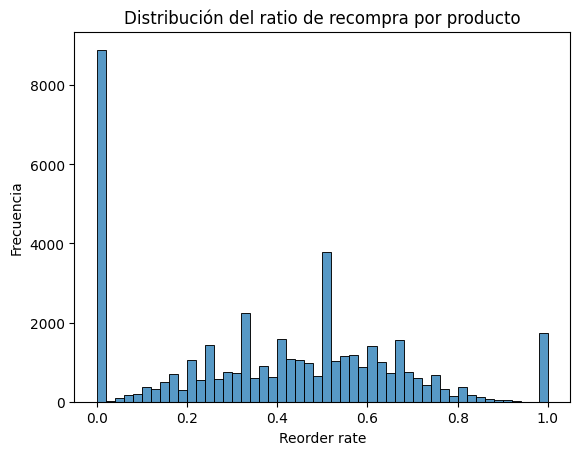

In [48]:
plt.figure()
sns.histplot(reorder_by_product["reorder_rate"], bins=50)
plt.title("Distribución del ratio de recompra por producto")
plt.xlabel("Reorder rate")
plt.ylabel("Frecuencia")
plt.show()

In [49]:
top_reorder = reorder_by_product.sort_values(
    by="reorder_rate", ascending=False
).head(20)

top_reorder

,product_id,product_name,reorder_rate
11995,13421,Advanced Care Plaque Guard Frosted Mint Antipl...,1.0
39837,44412,Seafood Magic Seasoning Blends,1.0
26235,29201,Pretzels Sesame Baked Not Fried,1.0
26251,29219,Homestyle Salisbury Steak,1.0
39865,44440,Purrfect Delicacies Multi-pack,1.0
26278,29247,Lake Shore Blend Medium Roast Coffee,1.0
39859,44434,Juice Squeeze Wild Berry,1.0
39854,44429,Riesling Blue Qba,1.0
26340,29321,Toffee Crunch Milk Chocolate Bar,1.0
27155,30236,Organic Carob Soymilk,1.0


**C4. Para cada usuario, ¿cual es la proporcion de re-compras de los productos comprados?**

In [50]:
reorder_by_user = (
    obt.groupby("user_id")["reordered"]
    .mean()
    .reset_index(name="user_reorder_rate")
)

In [51]:
reorder_by_user["user_reorder_rate"].describe()

count    149626.000000
mean          0.494853
std           0.292685
min           0.000000
25%           0.272727
50%           0.500000
75%           0.724138
max           1.000000
Name: user_reorder_rate, dtype: float64

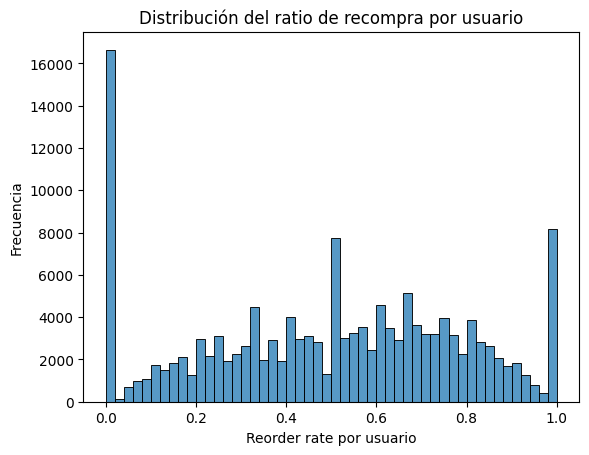

In [52]:
plt.figure()
sns.histplot(reorder_by_user["user_reorder_rate"], bins=50)
plt.title("Distribución del ratio de recompra por usuario")
plt.xlabel("Reorder rate por usuario")
plt.ylabel("Frecuencia")
plt.show()

In [53]:
top_users = reorder_by_user.sort_values(
    by="user_reorder_rate", ascending=False
).head(20)

top_users

,user_id,user_reorder_rate
99672,137587,1.0
125732,173474,1.0
10138,13918,1.0
45067,62300,1.0
45074,62307,1.0
69811,96301,1.0
45076,62312,1.0
35222,48616,1.0
45079,62316,1.0
138633,191162,1.0


**C5. ¿Cuales son los top 20 productos que los clientes ponen primero en sus carritos?**

In [54]:
top_first_products = (
    obt[obt["add_to_cart_order"] == 1]
    .groupby(["product_id", "product_name"])
    .size()
    .reset_index(name="first_count")
    .sort_values(by="first_count", ascending=False)
    .head(20)
)

top_first_products

,product_id,product_name,first_count
13280,24852,Banana,15562
7051,13176,Bag of Organic Bananas,11026
14881,27845,Organic Whole Milk,4363
11266,21137,Organic Strawberries,3946
25195,47209,Organic Hass Avocado,3390
11665,21903,Organic Baby Spinach,3336
25485,47766,Organic Avocado,3044
10507,19660,Spring Water,2336
8955,16797,Strawberries,2308
14955,27966,Organic Raspberries,2024


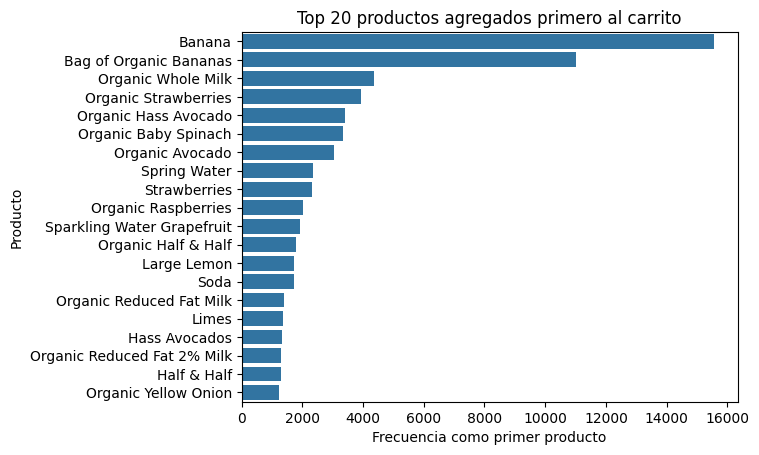

In [55]:
plt.figure()
sns.barplot(
    data=top_first_products,
    x="first_count",
    y="product_name"
)
plt.title("Top 20 productos agregados primero al carrito")
plt.xlabel("Frecuencia como primer producto")
plt.ylabel("Producto")
plt.show()

### Tus conclusiones avanzadas [Grupo C]:
(Enuncia las posibles relaciones matemáticas encontradas o variables dispersas)

# Conclusión General Ejecutiva
Resume en un párrafo las principales fortalezas, falencias detectadas en la gobernanza inicial de este dataset, y los descubrimientos de negocio clave que proporcionarías a la directiva de Instacart.

### C1. Tamaño de la canasta comercial

El análisis del tamaño de la canasta muestra que, en promedio, los usuarios compran aproximadamente 10.1 productos por orden, mientras que la mediana se ubica en 8 productos. Esto indica que el comportamiento típico de compra se concentra en órdenes de tamaño moderado. Además, el rango intercuartílico (entre 5 y 14 productos) evidencia que la mayoría de las órdenes se encuentran dentro de este intervalo.

La distribución observada es claramente asimétrica positiva (sesgada a la derecha), como se aprecia en el histograma. Existe una alta concentración de órdenes pequeñas y medianas, mientras que una menor proporción de órdenes presenta tamaños considerablemente grandes, extendiendo la cola de la distribución hasta valores elevados (más de 100 productos).

El boxplot confirma la presencia de numerosos valores atípicos en la parte superior de la distribución. Esto indica que, aunque la mayoría de los usuarios realiza compras de tamaño moderado, existe un subconjunto reducido que efectúa compras significativamente más grandes.

En términos de curtosis, el valor obtenido (aproximadamente 4.13) indica que la distribución es leptocúrtica. Esto implica una alta concentración de observaciones alrededor de la media y la presencia de colas pesadas, lo que refleja una mayor frecuencia de valores extremos en comparación con una distribución normal.

En conjunto, estos resultados sugieren la coexistencia de dos patrones de comportamiento: compras regulares de tamaño medio y compras de gran volumen asociadas a abastecimiento. Esta heterogeneidad en el tamaño de la canasta representa una oportunidad para segmentar estrategias comerciales en función del comportamiento de compra.

### C2. ¿Son los primeros productos un síntoma de fidelidad?

El análisis de los productos que con mayor frecuencia son agregados en la posición #1 del carrito permite evaluar si existe una relación entre este comportamiento y la fidelidad del consumidor, medida a través del ratio de recompra (reordered).

A partir de los 20 productos más frecuentes en la primera posición del carrito, se comparó su frecuencia de aparición como primer producto con su tasa de recompra global. El gráfico de dispersión muestra una tendencia positiva, aunque con cierta dispersión entre los puntos.

El coeficiente de correlación de Spearman obtenido es aproximadamente 0.48, lo que indica una correlación positiva moderada entre ambas variables. Esto sugiere que los productos que aparecen con mayor frecuencia como primer elemento del carrito tienden, en general, a tener mayores tasas de recompra.

Sin embargo, la relación no es fuerte ni perfectamente consistente, lo que implica que ser agregado primero no garantiza necesariamente una alta fidelidad, sino que incrementa su probabilidad.

Este patrón puede interpretarse como evidencia de que muchos de los productos añadidos en primera posición corresponden a productos de consumo habitual o recurrente, que los usuarios priorizan al iniciar su compra.

En conclusión, existe una relación positiva moderada entre ser agregado como primer producto y la fidelidad del consumidor, lo que sugiere que estos productos actúan como indicadores parciales de hábitos de recompra, pero no como un determinante absoluto.

### C3. Para cada producto, ¿cuál es la proporción de recompras?

La proporción de recompras por producto se calculó como el promedio de la variable `reordered` para cada producto, lo que permite estimar la probabilidad de que un producto sea vuelto a comprar una vez adquirido.

Los estadísticos descriptivos muestran que la media del ratio de recompra es aproximadamente 0.39, lo que indica que, en promedio, los productos son recomprados en cerca del 39% de los casos. Sin embargo, la desviación estándar es relativamente alta (≈ 0.27), lo que evidencia una importante variabilidad entre productos.

El análisis de la distribución revela un comportamiento heterogéneo. Se observa una fuerte concentración de productos con tasas de recompra cercanas a 0, lo que sugiere la existencia de muchos productos que son comprados una sola vez o de forma muy ocasional. Al mismo tiempo, existe una masa relevante de productos con tasas de recompra medias y altas, así como un grupo reducido con valores cercanos a 1.

Este patrón indica la coexistencia de distintos tipos de productos dentro del catálogo: por un lado, productos de baja recurrencia asociados a compras esporádicas o específicas; por otro lado, productos altamente recurrentes que forman parte del consumo habitual de los usuarios.

Adicionalmente, el hecho de que algunos productos presenten una tasa de recompra igual a 1 debe interpretarse con cautela, ya que puede deberse a un bajo número de observaciones para esos productos, lo que inflaría artificialmente su ratio.

En conclusión, la proporción de recompra varía significativamente entre productos, reflejando distintos niveles de fidelidad y permitiendo identificar categorías de consumo recurrente frente a compras ocasionales.

### C4. Para cada usuario, ¿cuál es la proporción de recompras de los productos comprados?

La proporción de recompras por usuario se calculó como el promedio de la variable `reordered` para cada usuario, lo que permite medir qué tan frecuentemente un cliente vuelve a comprar productos previamente adquiridos.

Los estadísticos descriptivos muestran que la media del ratio de recompra es aproximadamente 0.49, mientras que la mediana es 0.50, lo que indica que, en promedio, cerca de la mitad de los productos que un usuario compra corresponden a recompras. La desviación estándar (≈ 0.29) evidencia una alta variabilidad en los comportamientos de los usuarios.

El análisis de la distribución revela una concentración importante en valores intermedios, particularmente entre 0.3 y 0.8, lo que sugiere que la mayoría de los usuarios combina compras recurrentes con exploración de nuevos productos. Sin embargo, también se observa una masa significativa de usuarios con tasas cercanas a 0, así como un grupo relevante con valores cercanos a 1.

La presencia de usuarios con ratio de recompra igual a 1 indica comportamientos altamente fieles, donde prácticamente todos los productos comprados corresponden a artículos previamente adquiridos. No obstante, estos casos deben interpretarse con cautela, ya que pueden estar influenciados por un bajo número de órdenes, lo que puede sesgar el indicador.

En conjunto, estos resultados reflejan la coexistencia de distintos perfiles de consumidores: usuarios altamente fieles con patrones de compra repetitivos, usuarios mixtos que combinan exploración y recurrencia, y usuarios con baja fidelidad que presentan comportamientos más variables.

En conclusión, la proporción de recompra a nivel de usuario muestra una distribución amplia y heterogénea, permitiendo identificar segmentos claros de comportamiento que pueden ser utilizados para estrategias de personalización y segmentación de clientes.

### C5. ¿Cuáles son los top 20 productos que los clientes ponen primero en sus carritos?

El análisis de los productos agregados en la posición #1 del carrito muestra una clara concentración en ciertos artículos que los usuarios priorizan al iniciar su compra.

Los resultados evidencian que productos como *Banana* y *Bag of Organic Bananas* dominan ampliamente esta categoría, con una frecuencia significativamente mayor que el resto. A estos les siguen productos como *Organic Whole Milk*, *Organic Strawberries*, *Organic Hass Avocado* y *Organic Baby Spinach*, lo que revela un patrón consistente.

Se observa que muchos de los productos pertenecen a categorías de alimentos frescos y básicos, particularmente frutas, verduras y lácteos, además de una fuerte presencia de productos orgánicos. Esto sugiere que los usuarios tienden a comenzar sus compras con productos esenciales y de consumo recurrente.

El comportamiento identificado refleja un proceso de compra estructurado, donde ciertos productos actúan como “anclas” del carrito. Estos productos no solo son frecuentes, sino también altamente predecibles, lo que indica hábitos de consumo bien establecidos.

Adicionalmente, la fuerte concentración en pocos productos es consistente con el principio de Pareto, donde una pequeña cantidad de productos concentra una gran proporción de las decisiones iniciales de compra.

Desde una perspectiva de negocio, estos productos representan puntos clave de entrada al proceso de compra, por lo que pueden ser estratégicamente utilizados para optimizar recomendaciones, promociones y estrategias de cross-selling.

En conclusión, los productos más frecuentemente añadidos en la primera posición del carrito corresponden principalmente a bienes básicos y recurrentes, evidenciando hábitos de compra estructurados y altamente predecibles por parte de los usuarios.